In [39]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import random
import numpy as np

centroids = [(-5,-5), (5,5), (-2.5, 2.5),(2.5,-2.5)]
cluster_std = [1,1,1,1]

In [40]:
X,y = make_blobs(n_samples=100,cluster_std=cluster_std,centers=centroids,n_features=4,random_state=12)

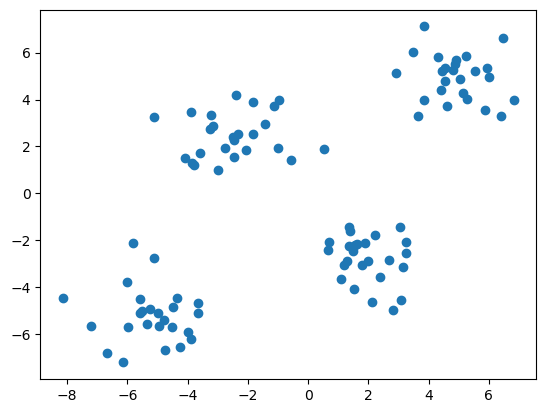

In [41]:
plt.scatter(X[:,0],X[:,1])

In [42]:
class KMeans:
    def __init__(self, n_clusters=2, max_iter=100):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.centroids = None

    def fit_predict(self,X):
        random_index = random.sample(range(0,X.shape[0]),self.n_clusters)
        self.centroids = X[random_index]

        for i in range(self.max_iter):
            # assign cluster
            cluster_group = self.assign_clusters(X)
            old_centroids = self.centroids
            # move centroids
            self.centroids = self.move_centroids(X, cluster_group)
            # check finish
            if (old_centroids ==self.centroids).all():
                break

        return cluster_group


    def assign_clusters(self,X):
        cluster_group = []
        distances = []

        for row in X:
            for centroid in self.centroids:
                # eucledian distance is equal to dot product for this case
                distances.append(np.sqrt(np.dot(row-centroid,row-centroid)))
            min_distance = min(distances)
            index_ps = distances.index(min_distance)
            cluster_group.append(index_ps)
            distances.clear()
        return np.array(cluster_group)
    
    def move_centroids(self,X,cluster_group):
        new_centroid = []
        cluster_type = np.unique(cluster_group)

        for type in cluster_type:
            new_centroid.append(X[cluster_group==type].mean(axis=0))
        
        return np.array(new_centroid)

        

In [43]:
kmeans = KMeans(n_clusters=4, max_iter=100)
y_means = kmeans.fit_predict(X)

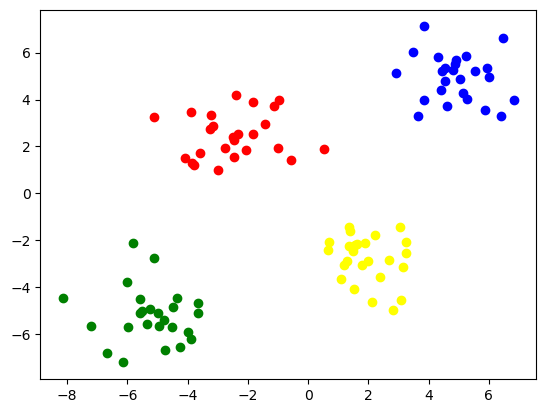

In [44]:
plt.scatter(X[y_means == 0,0], X[y_means == 0,1], color='red')
plt.scatter(X[y_means == 1,0], X[y_means == 1,1], color='blue')
plt.scatter(X[y_means == 2,0], X[y_means == 2,1], color='green')
plt.scatter(X[y_means == 3,0], X[y_means == 3,1], color='yellow')